In [87]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [88]:
torch.manual_seed(42) # ex: for random weights

X,y=make_classification(n_samples=1000,n_features=3,n_informative=3,n_redundant=0,random_state=42)

# 2. SPLIT THE DATA (Train: 70%, Val: 15%, Test: 15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

In [89]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_val_scaled=scaler.transform(X_val)

# 4. CONVERT TO PYTORCH TENSORS
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(X_train_t)



tensor([[-0.0767, -1.5488, -0.2287],
        [ 0.0691, -2.8254,  1.3728],
        [ 0.7999,  1.4397,  2.5921],
        ...,
        [ 1.8928, -0.1982,  0.8584],
        [ 0.9926, -0.4469,  0.3218],
        [-2.7565,  0.1593, -2.6798]])


In [90]:
train_dataset=TensorDataset(X_train_t,y_train_t) # combine train x and y again
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)#says to push 32 by 32, 32 choose after shuffle each time

In [91]:

class CustomerPredicter(nn.Module):

    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(3, 8)
        self.output = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.hidden(x))
        return self.output(x)

model = CustomerPredicter()
print(model)
print(model.parameters())      

CustomerPredicter(
  (hidden): Linear(in_features=3, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
)
<generator object Module.parameters at 0x7fb2a7fa0b80>


In [92]:
print(model.parameters())

<generator object Module.parameters at 0x7fb2a7fa0b80>


In [93]:
loss_function=nn.BCEWithLogitsLoss()

optimizer=optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)


In [94]:
epochs=50
val_losses=[]
train_loss=[]
CHECKPOINT_PATH="best_customer_predictor.pt"# best model will be saved like this
best_val_loss=float('inf') #start with infinity

for epoch in range (epochs): #for 700 data
       
       model.train()
       epoch_train_loss=0.0# batch vise training loss


       for batch_X,batch_Y in train_loader:#for 32 batches
              
              optimizer.zero_grad() #clear old gradient values for each batch at the begining of each batch

              logits=model(batch_X) #store logits u get from froward function #contain 32 values

              loss=loss_function(logits,batch_Y) # BCE and sigmoid #only 1 values which is average

              loss.backward()#backpropagation #calculate gradients

              optimizer.step() #update parameters base on gradients

              epoch_train_loss += loss.item() # get the traing loss for current batch and add to currrent epoch train loss, when full ephoch is over ge get the this final value and / number of batches and get average

       average_train_loss_per_epoch=epoch_train_loss/len(train_loader)
       train_loss.append(average_train_loss_per_epoch)

       model.eval() # start eval mode, auto stop train mode for first epoch #turn off dropout layer

       with torch.no_grad(): #turn off gadient calcs,we dont need it on val and test process
              val_logits=model(X_val_t)
              val_loss=loss_function(val_logits,y_val_t)
       val_losses.append(val_loss.item())

       if val_loss.item() < best_val_loss :
              best_val_loss=val_loss.item()
              torch.save(model.state_dict(),CHECKPOINT_PATH)

       if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {average_train_loss_per_epoch:.4f} | Val Loss: {val_loss.item():.4f}")
       


              


Epoch 10/50 | Train Loss: 0.4554 | Val Loss: 0.4309
Epoch 20/50 | Train Loss: 0.2665 | Val Loss: 0.2666
Epoch 30/50 | Train Loss: 0.2080 | Val Loss: 0.2297
Epoch 40/50 | Train Loss: 0.1889 | Val Loss: 0.2217
Epoch 50/50 | Train Loss: 0.1799 | Val Loss: 0.2182


In [95]:
try:
    chkp=torch.load(CHECKPOINT_PATH,map_location="cpu",weights_only=True) #cpu , if model trained on gpu and saved on gpu this helps pt to load it to cpu 
except:
     chkp=torch.load(CHECKPOINT_PATH,map_location="cpu")#for old versions

#currently model have weights and bias for 50th run last batch, but here we load best para with pt we saved
model.load_state_dict(chkp)
print(chkp)

OrderedDict({'hidden.weight': tensor([[ 1.0088,  0.6265,  0.1045],
        [ 1.2544, -0.1938,  0.3247],
        [-1.0504,  0.2370,  0.5675],
        [-0.1687,  0.6427,  0.4297],
        [ 1.1394,  0.0275,  0.3862],
        [ 0.4163,  0.7849,  0.4444],
        [-1.0833, -0.2559, -0.8392],
        [-0.8876, -0.6087,  0.2177]]), 'hidden.bias': tensor([ 0.2378,  0.3756,  0.3369, -0.1546,  0.6681,  0.1282,  0.9598,  0.1276]), 'output.weight': tensor([[ 0.7805,  0.6322, -0.8051,  0.2793,  0.5497,  0.7751, -0.5869, -0.7203]]), 'output.bias': tensor([-0.0896])})


In [96]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

with torch.no_grad():
    test_logits = model(X_test_t)
    test_prob = torch.sigmoid(test_logits).cpu().numpy().ravel()
    y_true = y_test_t.cpu().numpy().ravel()
    y_pred = (test_prob >= 0.5).astype(int)

print("Predicted labels:")
print(y_pred)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))  

Predicted labels:
[1 1 0 1 1 1 1 1 0 0 1 0 1 0 1 1 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1
 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 0 1 0 0 0 1 0 1
 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 0
 0 0 0 0 0 1 0 1 0 0 1 1 1 0 0 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 1 0 1 0 0 1 0
 1 0]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.89        81
         1.0       0.87      0.88      0.88        69

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150


Confusion Matrix:
[[72  9]
 [ 8 61]]


In [97]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.8866666666666667


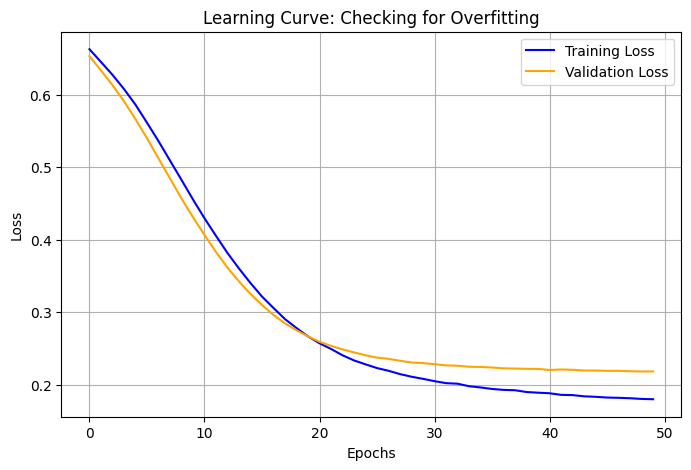

In [98]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.title('Learning Curve: Checking for Overfitting')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [108]:
#infarance

new_cus_data=[[1.5,2.0,0.8]]

new_data_t=torch.tensor(new_cus_data,dtype=torch.float32)

print(new_data_t)


model.eval()

with torch.no_grad():
    new_logits=model(new_data_t)
    new_data_prob=torch.sigmoid(new_logits)
    print(new_data_prob.item())



if new_data_prob>=0.5:
    print("cus will buy it")
    

tensor([[1.5000, 2.0000, 0.8000]])
0.9994949102401733
cus will buy it
